In [ ]:
# 04 – Review Classification

#This notebook builds a text classifier that sorts reviews into the nine categories from `docs/labeling_guide.md`. It covers creating a labeled dataset, training a baseline model, evaluating it, and comparing it with an LLM-based classifier.

In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("../data/processed/reviews.db")

# only reviews with usable text (English, 3+ words), from Phase 3
df = pd.read_sql("SELECT reviewId, app_name, score, content FROM reviews WHERE usable_text = 1", conn)
conn.close()

print("Usable reviews:", len(df))

Usable reviews: 48499


In [2]:
#pick 500 reviews to label and split it training and test sets
# 25 reviews for every app and every star rating: 4 apps x 5 ratings x 25 = 500
sample = df.groupby(["app_name", "score"]).sample(n=25, random_state=42)

# shuffle the rows so apps and ratings are mixed together while labeling
sample = sample.sample(frac=1, random_state=42).reset_index(drop=True)

print("Sampled:", len(sample))
print(sample.groupby("app_name").size())  # should be 125 per app

Sampled: 500
app_name
Credit Karma     125
Monarch Money    125
Rocket Money     125
YNAB             125
dtype: int64


In [4]:
# split into test and training sets and save them

# first 100 rows become the test set, the other 400 the training set
test = sample.iloc[:100].copy()
train = sample.iloc[100:].copy()

# add empty columns for you to fill in
for d in (test, train):
    d["category"] = ""
    d["notes"] = ""

test.to_csv("../data/labeled/to_label_test.csv", index=False)
train.to_csv("../data/labeled/to_label_train.csv", index=False)

print("Test:", len(test), "| Train:", len(train))

Test: 100 | Train: 400


In [5]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd

train = pd.read_csv("../data/labeled/labeled_train.csv")  # 400 reviews the model learns from
test = pd.read_csv("../data/labeled/labeled_test.csv")    # 100 reviews used only for grading

print("Train:", len(train), "| Test:", len(test))
print(train["category"].value_counts())  # how many examples per category

Train: 400 | Test: 100
category
Praise                      113
Pricing & subscription       65
Bank connection / sync       49
Usability & design           39
Other / off-topic            35
Bugs & performance           26
Missing features             25
Ads & upselling              25
Account, login & support     23
Name: count, dtype: int64


In [7]:
#build and train the model
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

model = make_pipeline(
    TfidfVectorizer(
        lowercase=True,        # treat "Sync" and "sync" as the same word
        stop_words="english",  # ignore very common words like "the" and "is"
        ngram_range=(1, 2),    # use single words and two-word phrases like "customer service"
        min_df=2               # ignore words that appear in only one review
    ),
    LogisticRegression(
        max_iter=1000,            # give the model enough steps to finish learning
        class_weight="balanced"   # give small categories fair attention, not just Praise
    )
)

model.fit(train["content"], train["category"])  # learn from the training reviews and their labels
print("Model trained!")

Model trained!


In [8]:
# test model 
from sklearn.metrics import classification_report, accuracy_score

predictions = model.predict(test["content"])  # model guesses categories for reviews it never saw

print("Accuracy:", round(accuracy_score(test["category"], predictions), 2))
print(classification_report(test["category"], predictions, zero_division=0))


''' Notes: 
Accuracy: the share of test reviews the model got right overall.
Precision: when the model says "Pricing," how often it's actually Pricing.
Recall: of all the real Pricing reviews, how many the model found.
F1-score: a single number combining precision and recall. Look at this one per category.
Support: how many test reviews were in each category.'''

Accuracy: 0.56
                          precision    recall  f1-score   support

Account, login & support       0.60      0.86      0.71         7
         Ads & upselling       0.62      1.00      0.77         5
  Bank connection / sync       0.69      0.73      0.71        15
      Bugs & performance       0.25      0.20      0.22         5
        Missing features       0.67      0.17      0.27        12
       Other / off-topic       0.44      0.50      0.47         8
                  Praise       0.67      0.54      0.60        26
  Pricing & subscription       0.54      0.58      0.56        12
      Usability & design       0.38      0.60      0.46        10

                accuracy                           0.56       100
               macro avg       0.54      0.58      0.53       100
            weighted avg       0.58      0.56      0.54       100



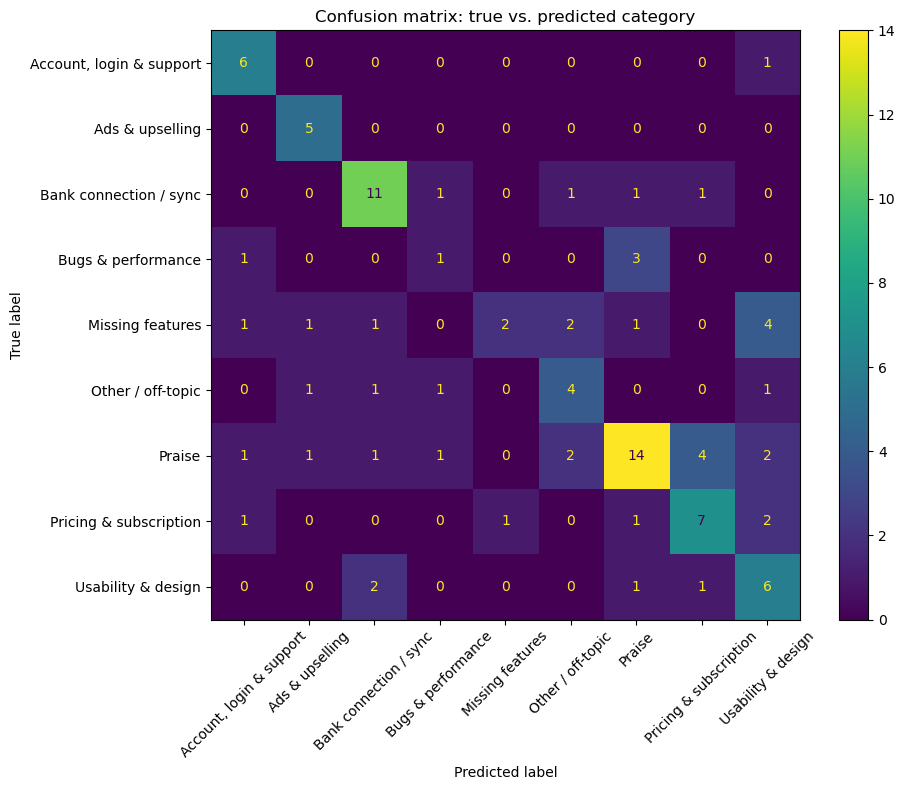

In [9]:
# See where model gets confused 

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    test["category"], predictions,
    xticks_rotation=45,   # tilt category names so they don't overlap
    ax=ax
)
plt.title("Confusion matrix: true vs. predicted category")
plt.tight_layout()
plt.show()

In [10]:
# compare a few model settings fairly
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC

def make_tfidf():
    # same text settings as before, plus sublinear_tf, which softens the effect of repeated words
    return TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2),
                           min_df=2, sublinear_tf=True)

candidates = {
    "Logistic regression (current)": model,
    "Logistic regression, C=5": make_pipeline(make_tfidf(),
        LogisticRegression(C=5, max_iter=1000, class_weight="balanced")),   # C=5: learns more detail from the words
    "Linear SVM": make_pipeline(make_tfidf(),
        LinearSVC(class_weight="balanced")),                                 # another popular text classifier
}

for name, candidate in candidates.items():
    # 5-fold cross-validation on the training set only; macro F1 treats all categories equally
    scores = cross_val_score(candidate, train["content"], train["category"], cv=5, scoring="f1_macro")
    print(f"{name}: {scores.mean():.2f}")

Logistic regression (current): 0.44
Logistic regression, C=5: 0.44
Linear SVM: 0.43


/Users/yumiko/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/yumiko/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/yumiko/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/yumiko/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/yumiko/anacon

In [11]:
# train the final model on all 500 labeled reviews

# evaluation is done, so now the model can learn from every labeled review (train + test)
labeled = pd.concat([train, test], ignore_index=True)

final_model = make_pipeline(
    TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2), min_df=2),
    LogisticRegression(max_iter=1000, class_weight="balanced")
)
final_model.fit(labeled["content"], labeled["category"])
print("Final model trained on", len(labeled), "reviews")

Final model trained on 500 reviews


In [12]:
## predict a category for every usable review
# df holds all usable reviews from Cell 1; if you restarted the notebook, run Cell 1 again first
df["category"] = final_model.predict(df["content"])  # predicted category for each review

# how sure the model is about each prediction (0 to 1)
df["confidence"] = final_model.predict_proba(df["content"]).max(axis=1).round(2)

print("Reviews categorized:", len(df))
print(df["category"].value_counts(normalize=True).round(3))  # share of reviews per category

Reviews categorized: 48499
category
Praise                      0.365
Other / off-topic           0.122
Pricing & subscription      0.110
Ads & upselling             0.106
Account, login & support    0.081
Bank connection / sync      0.068
Missing features            0.059
Usability & design          0.053
Bugs & performance          0.036
Name: proportion, dtype: float64


In [13]:
## spot check the predictions
# show 2 random reviews for each predicted category, to see if the results make sense
for cat, group in df.groupby("category"):
    print(f"\n=== {cat} ===")
    for text in group.sample(2, random_state=1)["content"]:
        print("-", text[:150])


=== Account, login & support ===
- won't let login uninstall and re did but won't login showd sn endless loading screen after you pit verification
- Beware of Credit Karma Money accounts. They let stolen debit card information be used and deny dispute claims if you have ever shopped at that vendor 

=== Ads & upselling ===
- With Credit Karma's help I was able to acquire a credit card without a credit score, and over the course of almost three years I've managed to get a s
- do not like ad ads when playing games

=== Bank connection / sync ===
- Logic fails to categorize some spends correctly, occasionally missing large spends entirely. I'm missing about 5 days of transactions despite the app 
- App.keeps stating,,oops-you hit a snag,,,,app. doesn't reset after the oops you hit a snag statement

=== Bugs & performance ===
- fantastic app. does all it promises, and then some.
- Forced to move off of mint after 10 years to this app that does nothing for me

=== Missing features ===
- Ab

In [14]:
## save the categories to your database

conn = sqlite3.connect("../data/processed/reviews.db")

# a separate table linking each review ID to its predicted category and confidence
df[["reviewId", "category", "confidence"]].to_sql("review_categories", conn,
                                                   if_exists="replace", index=False)

# quick check: join the two tables with SQL and count categories per app
check = pd.read_sql("""
SELECT r.app_name, c.category, COUNT(*) AS reviews
FROM reviews r
JOIN review_categories c ON r.reviewId = c.reviewId
GROUP BY r.app_name, c.category
ORDER BY r.app_name, reviews DESC
""", conn)

conn.close()
check

,app_name,category,reviews
0,Credit Karma,Praise,7167
1,Credit Karma,Other / off-topic,5096
2,Credit Karma,Ads & upselling,4834
3,Credit Karma,"Account, login & support",2783
4,Credit Karma,Missing features,1804
5,Credit Karma,Usability & design,1213
6,Credit Karma,Bank connection / sync,911
7,Credit Karma,Pricing & subscription,774
8,Credit Karma,Bugs & performance,637
9,Monarch Money,Praise,719


In [15]:
## SUMMARY

## Model results

'''- **Model:** TF-IDF (words and two-word phrases) + logistic regression with balanced class weights
- **Data:** 400 training and 100 test reviews, labeled with AI assistance and spot-checked against the labeling guide
- **Test accuracy:** 56%; test macro F1: 0.53; 5-fold cross-validation macro F1: 0.44
- **Strongest categories:** Ads & upselling, Account/login & support, Bank sync, which have distinctive vocabulary
- **Weakest categories:** Missing features (often confused with Usability) and Bugs & performance (often mistaken for Praise in mixed reviews)
- **Model comparison:** logistic regression with C=5 and a linear SVM scored the same (0.43–0.44), suggesting more labeled data, not a different model, is the main way to improve
- **Limitation:** Missing features and Bugs & performance are likely undercounted in the full dataset'''



'''"Spot checks show the model often labels Rocket Money subscription-detection complaints as Pricing, because of the word 'subscription.'"'''

'"Spot checks show the model often labels Rocket Money subscription-detection complaints as Pricing, because of the word \'subscription.\'"'

In [ ]:
conn.close()